In [1]:
# packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#nodes = 441
#elements = 800


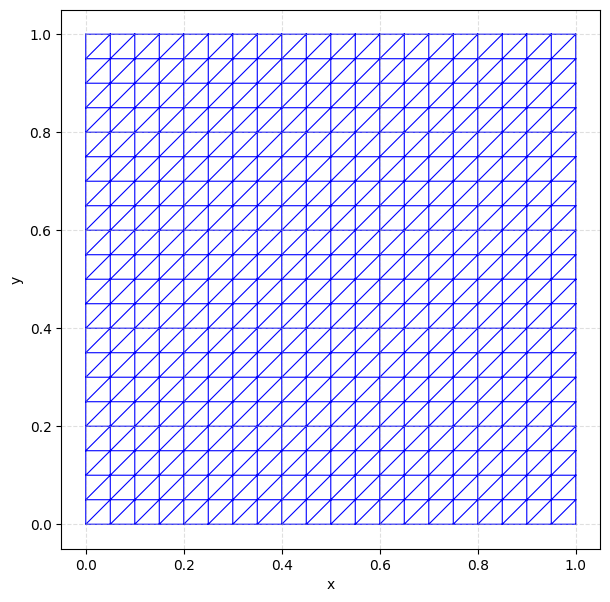

In [2]:
# uh.csv: Each row = x, y, u
# Th.csv: Each row = the three node numbers that make up an element
uh = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/fem/uh_square.csv", header=None).values
Th = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/fem/Th_square.csv", header=None).values.astype(int)

# Node coordinates
x = uh[:, 0]
y = uh[:, 1]
u = uh[:, 2]

# If node numbers in element data start at 1, change them to start at 0
if Th.min() == 1:
    Th = Th - 1

# check
n_node = len(x)
if Th.min() < 0 or Th.max() >= n_node:
    raise ValueError("The node numbers in Th are invalid.")

print(f"#nodes = {n_node}")
print(f"#elements = {len(Th)}")

# Triangulation
triang = mtri.Triangulation(x, y, Th)
plt.figure(figsize=(7, 7))
plt.triplot(triang, color='blue', linewidth=0.8)
plt.gca().set_aspect('equal')
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

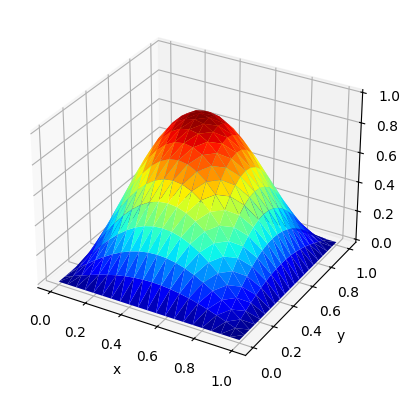

In [3]:
# data
coord = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/fem/uh_square.csv',header=None).values
x = coord[:,0]
y = coord[:,1]
z = coord[:,2]
tridata = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/fem/Th_square.csv',header=None).values
tri = mtri.Triangulation(x,y,triangles=tridata)

# plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(tri,z,cmap=plt.cm.jet)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.view_init(elev=30, azim=-60)
plt.savefig('/content/drive/MyDrive/Colab Notebooks/fem/uh_square.png',dpi=300, bbox_inches='tight')
plt.show()